QUESTION BY OR204 - Jizo

In [ ]:
# Practical Task

# Dataset

# Use the Titanic dataset from Seaborn:

# import seaborn as sns
# df = sns.load_dataset("titanic")

# Task

# Perform a mini EDA and data-quality analysis to determine what factors are associated with passenger survival.

# 1. Data Cleaning

# * Identify missing values and calculate missing-value percentages.
# * Handle missing values in age and embarked.
# * Identify potential outliers in fare using the IQR method.
# * Do not automatically remove outliers; justify your decision.

# 2. Summary Statistics

# For age, fare, and survived, calculate:

# * Mean
# * Median
# * Mode
# * Standard deviation
# * Skewness
# * Kurtosis

# 3. Visualization

# Create:

# * Histogram of fare with appropriate labels/title.
# * Bar plot showing survival rate by class.
# * Box plot of fare by class.
# * Violin plot of age by survived.
# * Correlation heatmap for numerical variables.

# 4. Correlation & Covariance

# Calculate:

# * Pearson correlation between age and fare.
# * Spearman correlation between age and fare.
# * Covariance between age and fare.
# * Correlation matrix.
# * Covariance matrix.

# Briefly explain why Pearson and Spearman may give different results.

# 5. Data Insights

# Identify at least 4 actionable insights, including:

# * One distribution-related insight.
# * One survival-related insight.
# * One outlier-related insight.
# * One correlation/covariance-related insight.

# Final Requirement

# Your notebook should contain:

# Data → Cleaning → Statistics → Visualizations → Correlation/Covariance → 4 Insights

Answers

In [15]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = sns.load_dataset("titanic")

In [8]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.isna().sum()/890 * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.887640
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224719
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.303371
embark_town     0.224719
alive           0.000000
alone           0.000000
dtype: float64

In [ ]:
df["age"].fillna(df["age"].median)
df["embarked"].fillna(df["embarked"].mode)

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: object

In [19]:
Q1 = df["age"].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = IQR * 1.5 - Q1
upper_limit = IQR * 1.5 + Q3

X = df["age"]

outliers = df[(X > upper_limit | X < lower_limit)]

print(outliers)

TypeError: Cannot perform 'ror_' with a dtyped [float64] array and scalar of type [bool]

In [23]:
df["age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

In [22]:
df["age"].skew()

np.float64(0.38910778230082704)

In [24]:
df["age"].kurtosis()

np.float64(0.17827415364210353)

In [25]:
df["fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

In [26]:
df["fare"].skew()

np.float64(4.787316519674893)

In [27]:
df["fare"].kurtosis()

np.float64(33.39814088089868)

In [28]:
df["survived"].describe()

count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: survived, dtype: float64

In [30]:
df["survived"].mode()

0    0
Name: survived, dtype: int64

In [31]:
df["survived"].skew()

np.float64(0.4785234382949897)

In [32]:
df["survived"].kurtosis()

np.float64(-1.775004671066304)

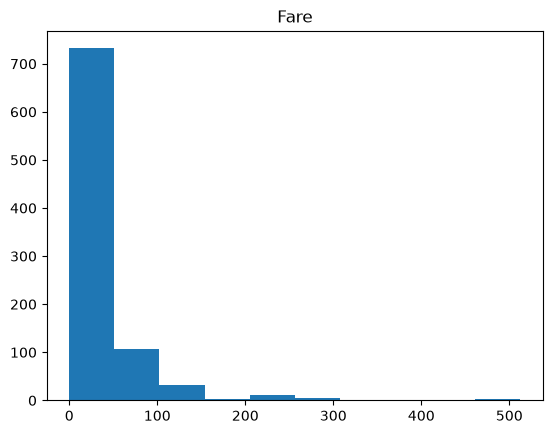

In [34]:
plt.hist(df["fare"])

plt.title("Fare")

plt.show()

<Axes: xlabel='class', ylabel='alive'>

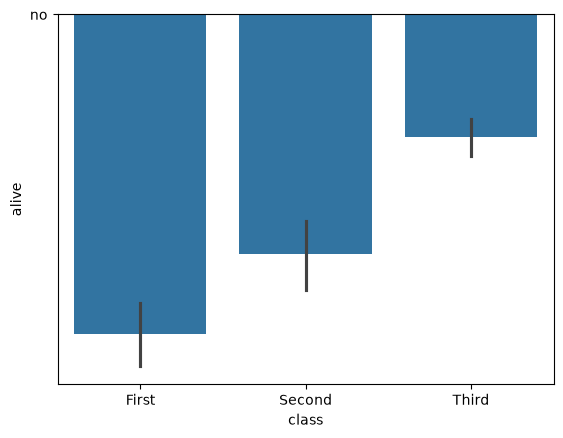

In [49]:
sns.barplot(x=df["class"], y=df["alive"])

<Axes: xlabel='fare', ylabel='class'>

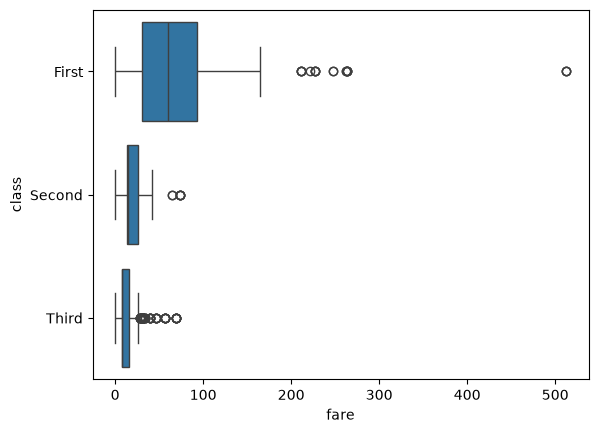

In [47]:
sns.boxplot(x=df["fare"], y=df["class"])

<Axes: xlabel='age', ylabel='alive'>

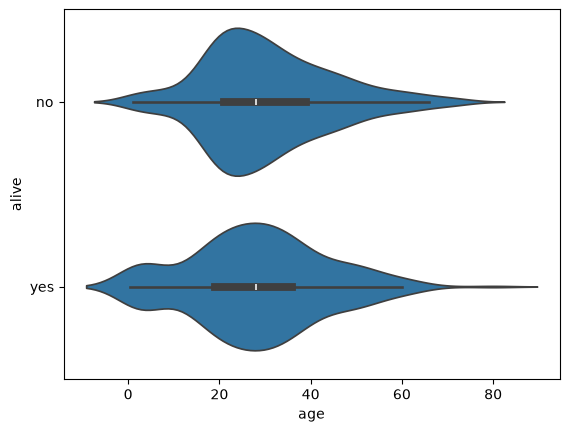

In [50]:
sns.violinplot(x=df["age"], y=df["alive"])